# Signal Strength Analysis for Na/Fe

This notebook checks whether the 6 color-style inputs in `NaFe_Dataset_Colors` carry enough signal for `Na/Fe`, and whether the apparent structure is being driven by subgroup effects such as `Paper` or `NGC`.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_DIR = Path().resolve()
PROJECT_ROOT_NAME = 'spectroscopy-regression'
while PROJECT_DIR.name != PROJECT_ROOT_NAME and PROJECT_DIR != PROJECT_DIR.parent:
    PROJECT_DIR = PROJECT_DIR.parent
os.chdir(PROJECT_DIR)
PROJECT_DIR


WindowsPath('C:/Users/phucl/Research/gc/spectroscopy-regression')

In [2]:
CSV_PATH = Path('data/Na_Fe_training_data.csv')

MAG_COLS = ['F275W_abs', 'F336W_abs', 'F438W_abs', 'F606W_abs', 'F814W_abs', 'Fe/H', 'age_Kruijssen']
TARGET_COL = 'Na/Fe'
RANGES = {
    'F275W_abs': (2, 10),
    'F336W_abs': (0, 6),
    'F438W_abs': (-2, 5),
    'F606W_abs': (-5, 4),
    'F814W_abs': (-5, 3),
}

df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=MAG_COLS + [TARGET_COL]).copy()
for col, (lo, hi) in RANGES.items():
    df = df[(df[col] >= lo) & (df[col] <= hi)]

features = pd.DataFrame({
    'F275W_minus_F336W': df['F275W_abs'] - df['F336W_abs'],
    'F336W_minus_F438W': df['F336W_abs'] - df['F438W_abs'],
    'F438W_minus_F606W': df['F438W_abs'] - df['F606W_abs'],
    'F606W_minus_F814W': df['F606W_abs'] - df['F814W_abs'],
    'Fe/H': df['Fe/H'],
    'age_Kruijssen': df['age_Kruijssen'],
}, index=df.index)
target = df[TARGET_COL].copy()

print('Filtered shape:', df.shape)
display(features.head())
display(target.describe())


Filtered shape: (245, 42)


,F275W_minus_F336W,F336W_minus_F438W,F438W_minus_F606W,F606W_minus_F814W,Fe/H,age_Kruijssen
0,3.2266,1.5003,1.6079,0.9815,-0.787,12.52
1,2.3369,0.9106,1.3140,0.8300,-0.771,12.52
2,2.6964,1.0734,1.6548,0.8973,-0.730,12.52
3,3.3320,1.7093,1.7314,1.0189,-0.779,12.52
4,2.2659,0.5998,1.2333,0.8011,-0.658,12.52


count    245.000000
mean       0.316266
std        0.282060
min       -0.420000
25%        0.091633
50%        0.330000
75%        0.528000
max        1.043150
Name: Na/Fe, dtype: float64

In [5]:
def eval_model(model, X, y, cv):
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    rmse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'pred': y_pred}

X = features.to_numpy()
y = target.to_numpy()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Mean baseline': DummyRegressor(strategy='mean'),
    'Linear': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearRegression()),
    'Ridge': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge(alpha=1.0)),
    'Lasso': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Lasso(alpha=0.001, max_iter=10000)),
    'RandomForest': RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1, min_samples_leaf=2),
}

rows = []
preds = {}
for name, model in models.items():
    result = eval_model(model, X, y, cv)
    rows.append({'model': name, 'RMSE': result['RMSE'], 'MAE': result['MAE'], 'R2': result['R2']})
    preds[name] = result['pred']

results = pd.DataFrame(rows).sort_values('RMSE')
display(results)


,model,RMSE,MAE,R2
4,RandomForest,0.052073,0.178358,0.342782
2,Ridge,0.060602,0.196461,0.235137
3,Lasso,0.060741,0.196368,0.233390
1,Linear,0.060891,0.196431,0.231489
0,Mean baseline,0.081466,0.237032,-0.028183


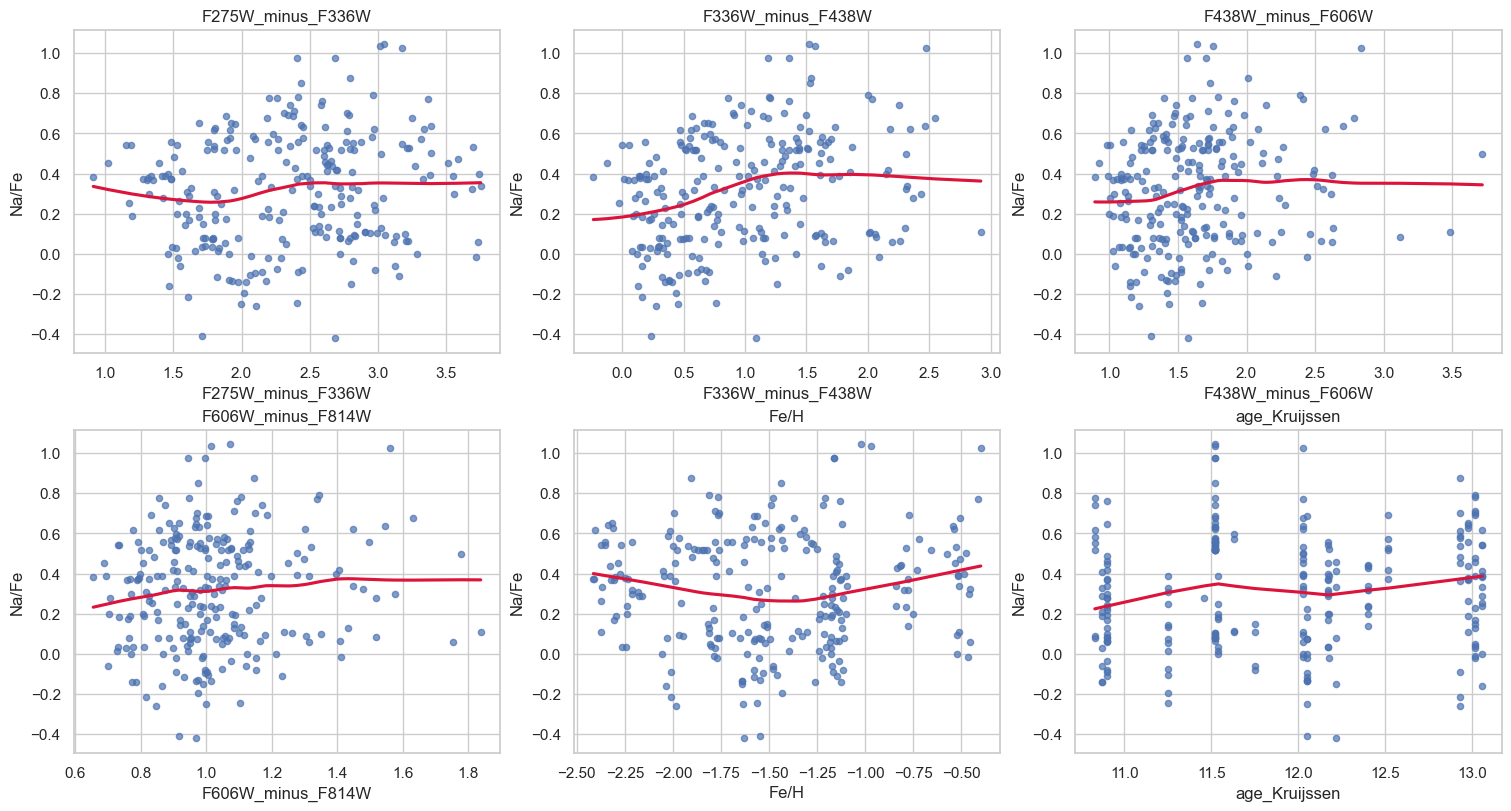

,pearson_corr
F336W_minus_F438W,0.271519
F438W_minus_F606W,0.142282
F275W_minus_F336W,0.137896
F606W_minus_F814W,0.096435
age_Kruijssen,0.090395
Fe/H,0.038492


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axes = axes.ravel()
for ax, col in zip(axes, features.columns):
    sns.regplot(x=features[col], y=target, lowess=True, scatter_kws={'s': 20, 'alpha': 0.7}, line_kws={'color': 'crimson'}, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
plt.show()

corr = pd.concat([features, target], axis=1).corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr.to_frame('pearson_corr'))


### How to read the feature plots

Each panel shows one input feature against `Na/Fe`, with a LOWESS curve on top. In this dataset the curves are the important part: if they are nearly flat, the feature carries little direct signal. If they slope or bend smoothly, there is some predictive structure, but a small correlation usually means the effect is weak rather than decisive.

For this dataset, `F336W_minus_F438W` is typically the strongest of the six inputs, but the others are only modestly related to `Na/Fe`. That means the 6-input space contains some signal, but probably not enough to separate all regimes on its own.


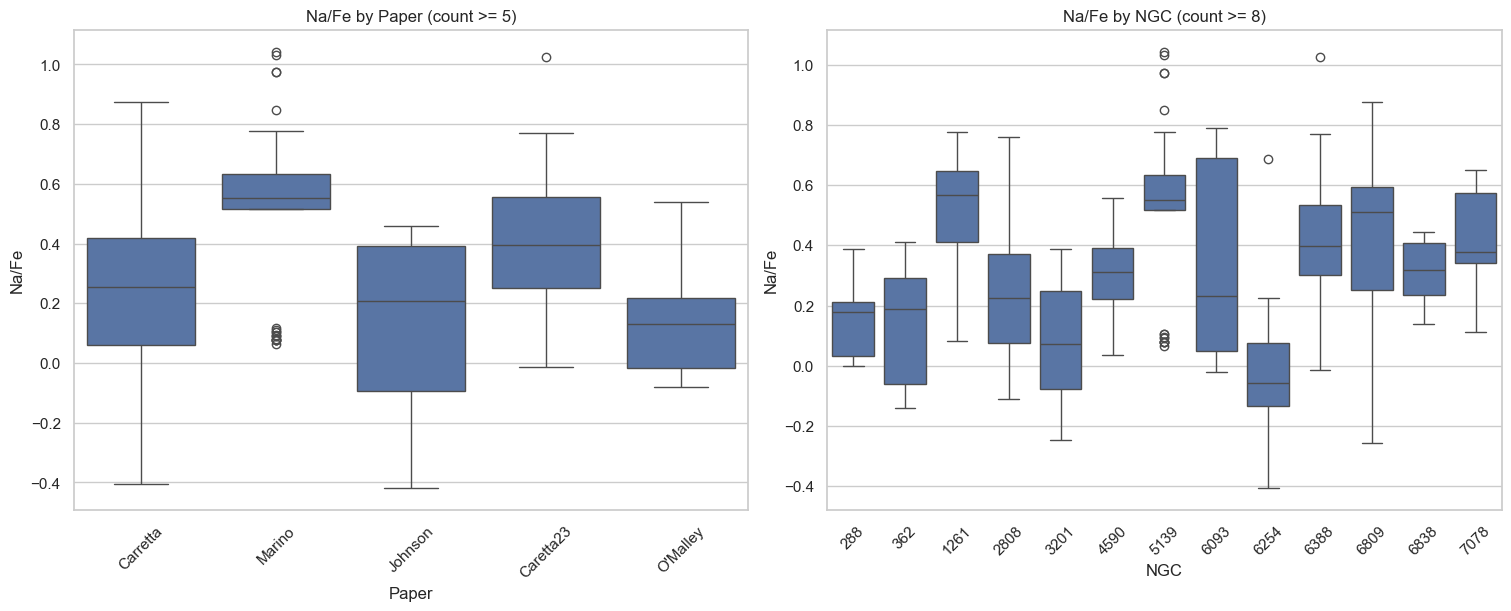

,count,mean,std,min,median,max
Paper,,,,,,
Carretta,155,0.252961,0.257426,-0.407000,0.256000,0.875000
Marino,53,0.503388,0.271039,0.065003,0.553593,1.043150
Caretta23,20,0.404050,0.270532,-0.014000,0.396000,1.024000
Johnson,6,0.118917,0.349615,-0.420000,0.206705,0.457515
O'Malley,6,0.150000,0.227508,-0.080000,0.130000,0.540000


,count,mean,std,min,median,max
NGC,,,,,,
5139,41,0.520211,0.273346,0.065003,0.549014,1.043150
2808,28,0.231786,0.216748,-0.111000,0.225000,0.759000
6388,21,0.408714,0.264547,-0.014000,0.399000,1.024000
6093,17,0.339412,0.302603,-0.020000,0.230000,0.790000
4590,14,0.310000,0.159817,0.036000,0.312000,0.556000
6254,14,-0.003214,0.258394,-0.407000,-0.057500,0.685000
3201,13,0.082846,0.201962,-0.246000,0.073000,0.387000
7078,12,0.414583,0.177260,0.111000,0.376500,0.650000
6809,12,0.385917,0.370092,-0.258000,0.512000,0.875000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

paper_counts = df['Paper'].value_counts()
top_papers = paper_counts[paper_counts >= 5].index
paper_df = df[df['Paper'].isin(top_papers)].copy()
sns.boxplot(data=paper_df, x='Paper', y=TARGET_COL, ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Na/Fe by Paper (count >= 5)')

ngc_counts = df['NGC'].value_counts()
top_ngc = ngc_counts[ngc_counts >= 8].index
ngc_df = df[df['NGC'].isin(top_ngc)].copy()
sns.boxplot(data=ngc_df, x='NGC', y=TARGET_COL, ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Na/Fe by NGC (count >= 8)')
plt.show()

display(paper_df.groupby('Paper')[TARGET_COL].agg(['count', 'mean', 'std', 'min', 'median', 'max']).sort_values('count', ascending=False))
display(ngc_df.groupby('NGC')[TARGET_COL].agg(['count', 'mean', 'std', 'min', 'median', 'max']).sort_values('count', ascending=False))


### How to read the subgroup plots

These boxplots check whether the same inputs are being measured under different source regimes. If different `Paper` groups or `NGC` clusters sit at clearly different `Na/Fe` levels, the model is facing a mixed distribution: the same kind of photometric input can map to different output offsets depending on where the sample came from.

That is exactly the kind of hidden structure that can make a regressor fall back to an average prediction. In other words, separation across papers or clusters is a sign that the dataset may need an explicit source variable, not just a stronger neural net.


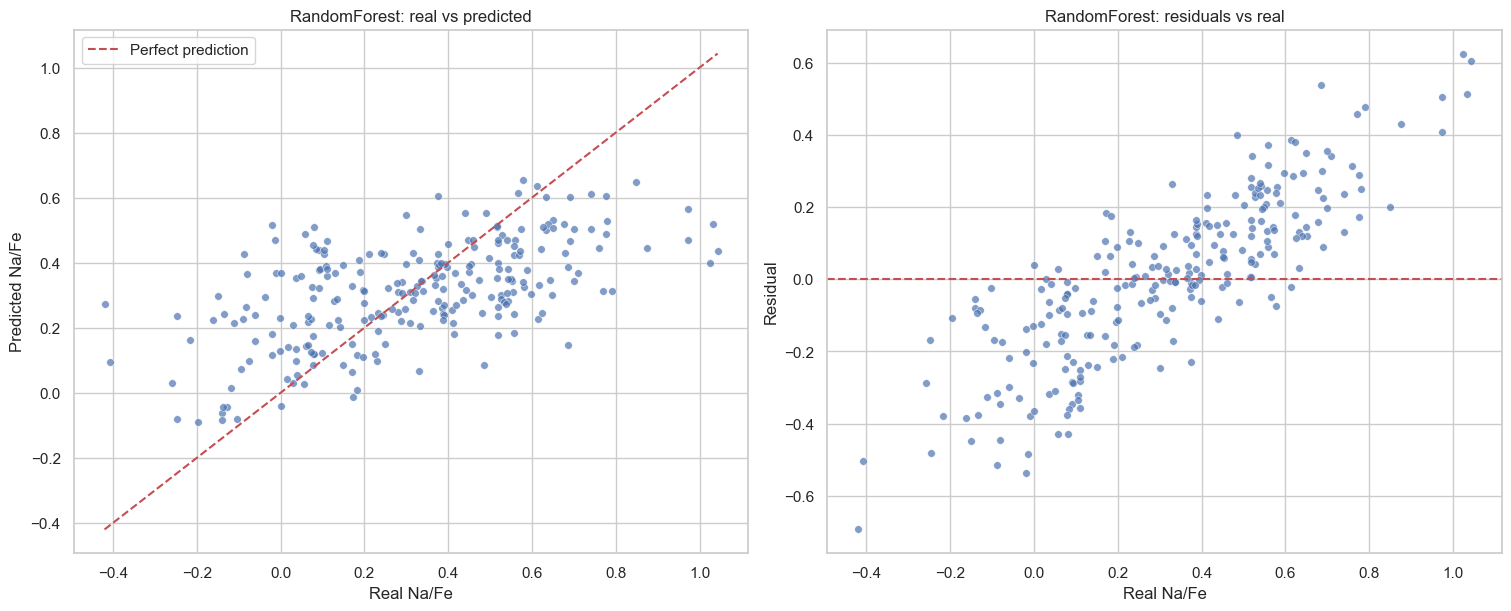

Best model: RandomForest
RMSE: 0.052073425974964
MAE: 0.17835841471306565
R2: 0.3427818328036767


In [ ]:
best_name = results.iloc[0]['model']
best_pred = preds[best_name]
residuals = target.to_numpy() - best_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
sns.scatterplot(x=target, y=best_pred, s=30, alpha=0.7, ax=axes[0])
lims = [min(target.min(), best_pred.min()), max(target.max(), best_pred.max())]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_title(f'{best_name}: real vs predicted')
axes[0].set_xlabel('Real Na/Fe')
axes[0].set_ylabel('Predicted Na/Fe')
axes[0].legend()

sns.scatterplot(x=target, y=residuals, s=30, alpha=0.7, ax=axes[1])
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title(f'{best_name}: residuals vs real')
axes[1].set_xlabel('Real Na/Fe')
axes[1].set_ylabel('Residual')
plt.show()


print('Best model:', best_name)
print('RMSE:', results.iloc[0]['RMSE'])
print('MAE:', results.iloc[0]['MAE'])
print('R2:', results.iloc[0]['R2'])


### How to read the residual plots

The left panel should ideally form a tight diagonal cloud around the dashed line. If the points collapse into a horizontal band, the model is predicting nearly the same value for almost every sample, which is the classic mean-prediction failure mode.

The right panel shows residuals versus the true value. A visible curve, fan shape, or sign bias means the model is systematically wrong in certain regions of the target range. If the residuals are large at the extremes and small near the center, the model is regressing toward the mean and missing the tails.


## What to look for

- If the mean baseline is almost as good as the nonlinear models, the 6 inputs are weak on their own.
- If `Paper` or `NGC` groups sit on different target bands, the dataset has hidden subgroup structure not represented in the 6 features.
- If RandomForest or Ridge beats the mean by a large margin, the inputs contain usable signal and the issue is more likely model/training specific.


In [6]:
# Verify whether subgroup identity helps explain Na/Fe
# If these models improve noticeably over the 6-feature baselines, the dataset likely has hidden source-specific structure.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

group_df = df[['Paper', 'NGC']].copy()
X_groups = pd.concat([features.reset_index(drop=True), group_df.reset_index(drop=True)], axis=1)
y_groups = target.reset_index(drop=True)

group_cv = KFold(n_splits=5, shuffle=True, random_state=42)

group_models = {
    'Ridge + groups': make_pipeline(
        ColumnTransformer(
            transformers=[
                ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), list(features.columns)),
                ('cat', OneHotEncoder(handle_unknown='ignore'), ['Paper', 'NGC']),
            ]
        ),
        Ridge(alpha=1.0),
    ),
    'RandomForest + groups': make_pipeline(
        ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), list(features.columns)),
                ('cat', OneHotEncoder(handle_unknown='ignore'), ['Paper', 'NGC']),
            ]
        ),
        RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1, min_samples_leaf=2),
    ),
}

group_rows = []
for name, model in group_models.items():
    result = eval_model(model, X_groups, y_groups, group_cv)
    group_rows.append({'model': name, 'RMSE': result['RMSE'], 'MAE': result['MAE'], 'R2': result['R2']})

group_results = pd.DataFrame(group_rows).sort_values('RMSE')
display(group_results)

print('Compare this against the 6-feature results above. A clear RMSE drop means Paper/NGC carry real predictive information.')


,model,RMSE,MAE,R2
1,RandomForest + groups,0.048608,0.171605,0.386517
0,Ridge + groups,0.049677,0.177672,0.373031


Compare this against the 6-feature results above. A clear RMSE drop means Paper/NGC carry real predictive information.


Train OOF -> RMSE: 0.0461 | MAE: 0.1662 | R2: 0.4179
Test fit  -> RMSE: 0.0601 | MAE: 0.1960 | R2: 0.2973


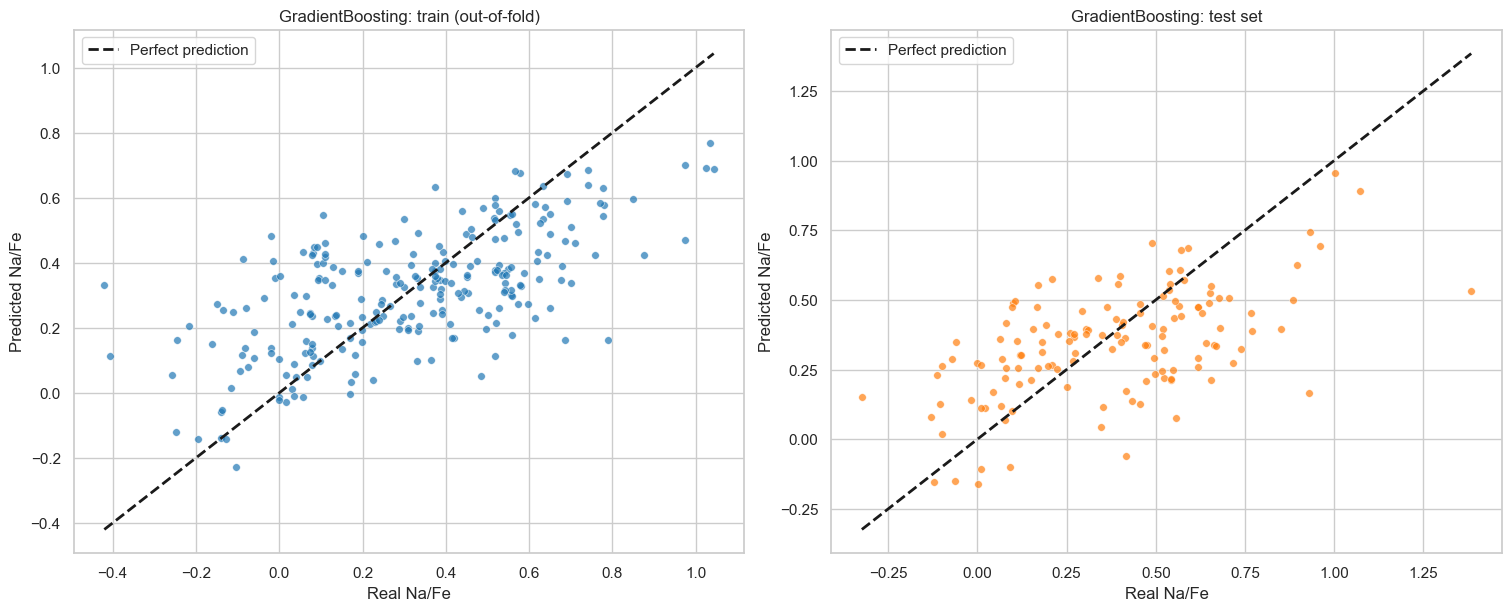

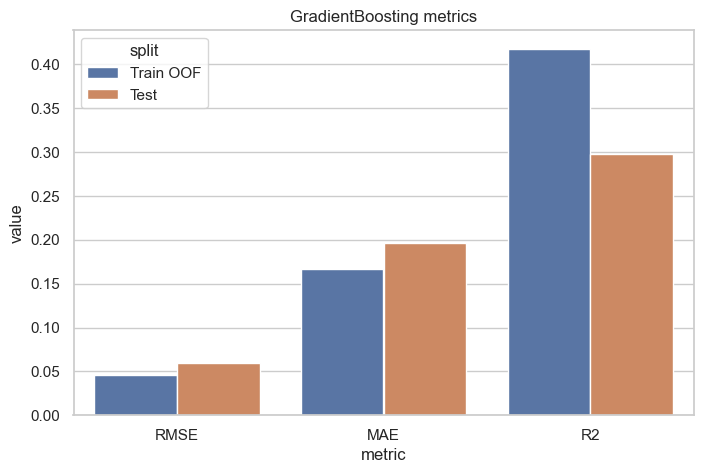

In [4]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Recreate the exact filtered feature set used by NaFe_Dataset_Colors
MAG_COLS = ['F275W_abs', 'F336W_abs', 'F438W_abs', 'F606W_abs', 'F814W_abs', 'Fe/H', 'age_Kruijssen']
TARGET_COL = 'Na/Fe'
RANGES = {
    'F275W_abs': (2, 10),
    'F336W_abs': (0, 6),
    'F438W_abs': (-2, 5),
    'F606W_abs': (-5, 4),
    'F814W_abs': (-5, 3),
}

def load_filtered_colors(csv_path):
    raw = pd.read_csv(csv_path)
    raw = raw.dropna(subset=MAG_COLS + [TARGET_COL]).copy()

    for col, (lo, hi) in RANGES.items():
        raw = raw[(raw[col] >= lo) & (raw[col] <= hi)]

    X = pd.DataFrame({
        'F275W_minus_F336W': raw['F275W_abs'] - raw['F336W_abs'],
        'F336W_minus_F438W': raw['F336W_abs'] - raw['F438W_abs'],
        'F438W_minus_F606W': raw['F438W_abs'] - raw['F606W_abs'],
        'F606W_minus_F814W': raw['F606W_abs'] - raw['F814W_abs'],
        'Fe/H': raw['Fe/H'],
        'age_Kruijssen': raw['age_Kruijssen'],
    }, index=raw.index)

    y = raw[TARGET_COL].copy()
    return X, y, raw

# Train set: use the filtered dataframe already loaded in earlier cells if present,
# otherwise load from disk.
try:
    X_train_gb = features.copy()
    y_train_gb = target.copy()
except NameError:
    X_train_gb, y_train_gb, _ = load_filtered_colors('data/Na_Fe_training_data.csv')

# External test set
X_test_gb, y_test_gb, _ = load_filtered_colors('data/Na_Fe_TEST_DATA.csv')

# K-fold on train set for out-of-fold predictions
gb_cv = KFold(n_splits=5, shuffle=True, random_state=42)
gb_model = GradientBoostingRegressor(random_state=42)

train_pred_oof = cross_val_predict(gb_model, X_train_gb, y_train_gb, cv=gb_cv, n_jobs=-1)

# Fit on full training set and predict test set
gb_model.fit(X_train_gb, y_train_gb)
test_pred = gb_model.predict(X_test_gb)

# Metrics
train_rmse = mean_squared_error(y_train_gb, train_pred_oof)
train_mae = mean_absolute_error(y_train_gb, train_pred_oof)
train_r2 = r2_score(y_train_gb, train_pred_oof)

test_rmse = mean_squared_error(y_test_gb, test_pred)
test_mae = mean_absolute_error(y_test_gb, test_pred)
test_r2 = r2_score(y_test_gb, test_pred)

print(f"Train OOF -> RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}")
print(f"Test fit  -> RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Train OOF plot
sns.scatterplot(x=y_train_gb, y=train_pred_oof, ax=axes[0], s=30, alpha=0.7, color='tab:blue')
train_lims = [min(y_train_gb.min(), train_pred_oof.min()), max(y_train_gb.max(), train_pred_oof.max())]
axes[0].plot(train_lims, train_lims, 'k--', lw=2, label='Perfect prediction')
axes[0].set_title('GradientBoosting: train (out-of-fold)')
axes[0].set_xlabel('Real Na/Fe')
axes[0].set_ylabel('Predicted Na/Fe')
axes[0].legend()

# Test plot
sns.scatterplot(x=y_test_gb, y=test_pred, ax=axes[1], s=30, alpha=0.7, color='tab:orange')
test_lims = [min(y_test_gb.min(), test_pred.min()), max(y_test_gb.max(), test_pred.max())]
axes[1].plot(test_lims, test_lims, 'k--', lw=2, label='Perfect prediction')
axes[1].set_title('GradientBoosting: test set')
axes[1].set_xlabel('Real Na/Fe')
axes[1].set_ylabel('Predicted Na/Fe')
axes[1].legend()

plt.show()

# Metric bar chart
fig, ax = plt.subplots(figsize=(8, 5))
metric_df = pd.DataFrame([
    {'split': 'Train OOF', 'RMSE': train_rmse, 'MAE': train_mae, 'R2': train_r2},
    {'split': 'Test', 'RMSE': test_rmse, 'MAE': test_mae, 'R2': test_r2},
])
metric_long = metric_df.melt(id_vars='split', var_name='metric', value_name='value')
sns.barplot(data=metric_long, x='metric', y='value', hue='split', ax=ax)
ax.set_title('GradientBoosting metrics')
plt.show()

Train OOF -> RMSE: 0.0521 | MAE: 0.1784 | R2: 0.3428
Test fit  -> RMSE: 0.0649 | MAE: 0.2014 | R2: 0.2412


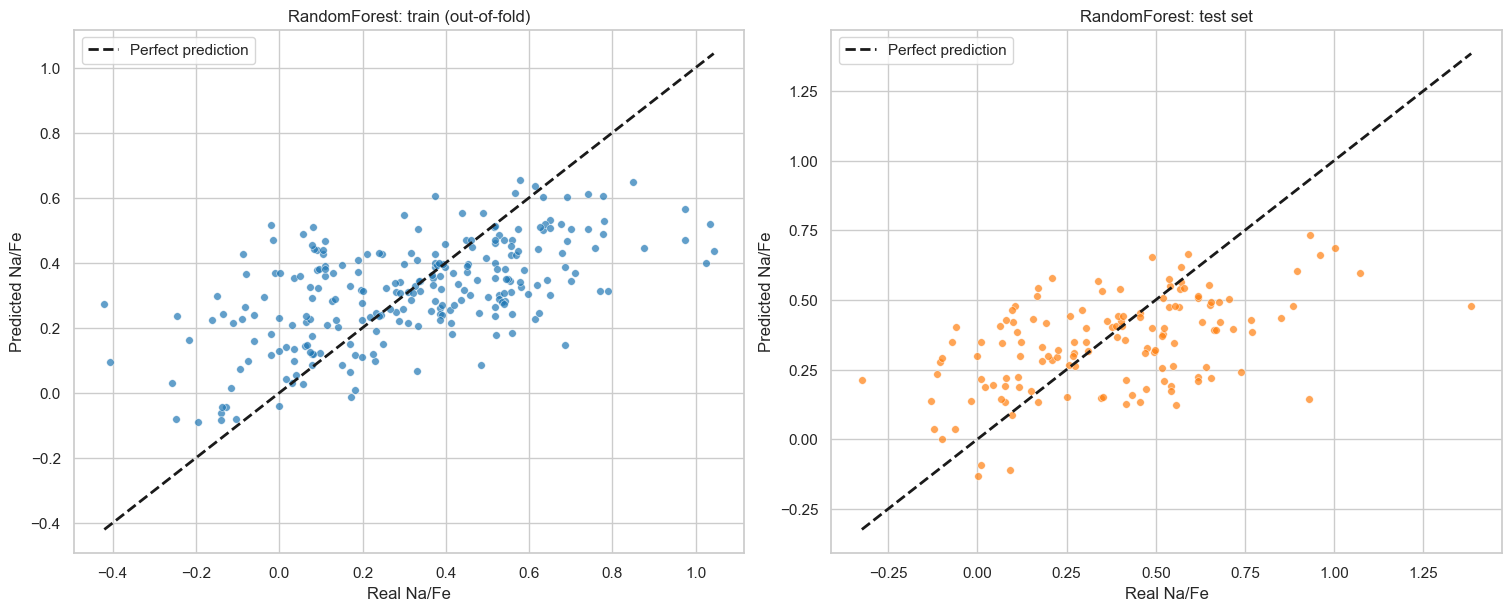

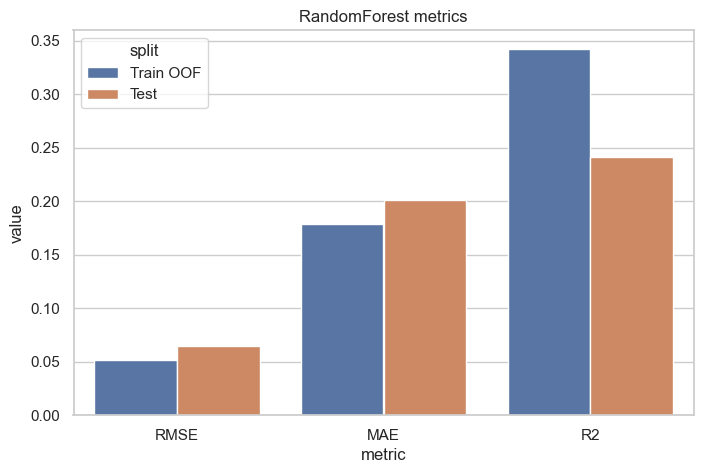

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Recreate the exact filtered feature set used by NaFe_Dataset_Colors
MAG_COLS = ['F275W_abs', 'F336W_abs', 'F438W_abs', 'F606W_abs', 'F814W_abs', 'Fe/H', 'age_Kruijssen']
TARGET_COL = 'Na/Fe'
RANGES = {
    'F275W_abs': (2, 10),
    'F336W_abs': (0, 6),
    'F438W_abs': (-2, 5),
    'F606W_abs': (-5, 4),
    'F814W_abs': (-5, 3),
}

def load_filtered_colors(csv_path):
    raw = pd.read_csv(csv_path)
    raw = raw.dropna(subset=MAG_COLS + [TARGET_COL]).copy()

    for col, (lo, hi) in RANGES.items():
        raw = raw[(raw[col] >= lo) & (raw[col] <= hi)]

    X = pd.DataFrame({
        'F275W_minus_F336W': raw['F275W_abs'] - raw['F336W_abs'],
        'F336W_minus_F438W': raw['F336W_abs'] - raw['F438W_abs'],
        'F438W_minus_F606W': raw['F438W_abs'] - raw['F606W_abs'],
        'F606W_minus_F814W': raw['F606W_abs'] - raw['F814W_abs'],
        'Fe/H': raw['Fe/H'],
        'age_Kruijssen': raw['age_Kruijssen'],
    }, index=raw.index)

    y = raw[TARGET_COL].copy()
    return X, y, raw

# Train set: use the filtered dataframe already loaded in earlier cells if present,
# otherwise load from disk.
try:
    X_train_rf = features.copy()
    y_train_rf = target.copy()
except NameError:
    X_train_rf, y_train_rf, _ = load_filtered_colors('data/Na_Fe_training_data.csv')

# External test set
X_test_rf, y_test_rf, _ = load_filtered_colors('data/Na_Fe_TEST_DATA.csv')

# K-fold on train set for out-of-fold predictions
rf_cv = KFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2,
)

train_pred_oof = cross_val_predict(rf_model, X_train_rf, y_train_rf, cv=rf_cv, n_jobs=-1)

# Fit on full training set and predict test set
rf_model.fit(X_train_rf, y_train_rf)
test_pred = rf_model.predict(X_test_rf)

# Metrics
train_rmse = mean_squared_error(y_train_rf, train_pred_oof)
train_mae = mean_absolute_error(y_train_rf, train_pred_oof)
train_r2 = r2_score(y_train_rf, train_pred_oof)

test_rmse = mean_squared_error(y_test_rf, test_pred)
test_mae = mean_absolute_error(y_test_rf, test_pred)
test_r2 = r2_score(y_test_rf, test_pred)

print(f"Train OOF -> RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}")
print(f"Test fit  -> RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Train OOF plot
sns.scatterplot(x=y_train_rf, y=train_pred_oof, ax=axes[0], s=30, alpha=0.7, color='tab:blue')
train_lims = [min(y_train_rf.min(), train_pred_oof.min()), max(y_train_rf.max(), train_pred_oof.max())]
axes[0].plot(train_lims, train_lims, 'k--', lw=2, label='Perfect prediction')
axes[0].set_title('RandomForest: train (out-of-fold)')
axes[0].set_xlabel('Real Na/Fe')
axes[0].set_ylabel('Predicted Na/Fe')
axes[0].legend()

# Test plot
sns.scatterplot(x=y_test_rf, y=test_pred, ax=axes[1], s=30, alpha=0.7, color='tab:orange')
test_lims = [min(y_test_rf.min(), test_pred.min()), max(y_test_rf.max(), test_pred.max())]
axes[1].plot(test_lims, test_lims, 'k--', lw=2, label='Perfect prediction')
axes[1].set_title('RandomForest: test set')
axes[1].set_xlabel('Real Na/Fe')
axes[1].set_ylabel('Predicted Na/Fe')
axes[1].legend()

plt.show()

# Metric bar chart
fig, ax = plt.subplots(figsize=(8, 5))
metric_df = pd.DataFrame([
    {'split': 'Train OOF', 'RMSE': train_rmse, 'MAE': train_mae, 'R2': train_r2},
    {'split': 'Test', 'RMSE': test_rmse, 'MAE': test_mae, 'R2': test_r2},
])
metric_long = metric_df.melt(id_vars='split', var_name='metric', value_name='value')
sns.barplot(data=metric_long, x='metric', y='value', hue='split', ax=ax)
ax.set_title('RandomForest metrics')
plt.show()